In [1]:
import pandas as pd

ames_housing = pd.read_csv(
    "../datasets/ames_housing_no_missing.csv",
    na_filter=False,  # required for pandas>2.0
)
target_name = "SalePrice"
data = ames_housing.drop(columns=target_name)
target = ames_housing[target_name]

In [2]:
numerical_features = [
    "LotFrontage", "LotArea", "MasVnrArea", "BsmtFinSF1", "BsmtFinSF2",
    "BsmtUnfSF", "TotalBsmtSF", "1stFlrSF", "2ndFlrSF", "LowQualFinSF",
    "GrLivArea", "BedroomAbvGr", "KitchenAbvGr", "TotRmsAbvGrd", "Fireplaces",
    "GarageCars", "GarageArea", "WoodDeckSF", "OpenPorchSF", "EnclosedPorch",
    "3SsnPorch", "ScreenPorch", "PoolArea", "MiscVal",
]

data_numerical = data[numerical_features]

data_numerical

,LotFrontage,LotArea,MasVnrArea,BsmtFinSF1,BsmtFinSF2,BsmtUnfSF,TotalBsmtSF,1stFlrSF,2ndFlrSF,LowQualFinSF,...,Fireplaces,GarageCars,GarageArea,WoodDeckSF,OpenPorchSF,EnclosedPorch,3SsnPorch,ScreenPorch,PoolArea,MiscVal
0,65.0,8450,196.0,706,0,150,856,856,854,0,...,0,2,548,0,61,0,0,0,0,0
1,80.0,9600,0.0,978,0,284,1262,1262,0,0,...,1,2,460,298,0,0,0,0,0,0
2,68.0,11250,162.0,486,0,434,920,920,866,0,...,1,2,608,0,42,0,0,0,0,0
3,60.0,9550,0.0,216,0,540,756,961,756,0,...,1,3,642,0,35,272,0,0,0,0
4,84.0,14260,350.0,655,0,490,1145,1145,1053,0,...,1,3,836,192,84,0,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1455,62.0,7917,0.0,0,0,953,953,953,694,0,...,1,2,460,0,40,0,0,0,0,0
1456,85.0,13175,119.0,790,163,589,1542,2073,0,0,...,2,2,500,349,0,0,0,0,0,0
1457,66.0,9042,0.0,275,0,877,1152,1188,1152,0,...,2,1,252,0,60,0,0,0,0,2500
1458,68.0,9717,0.0,49,1029,0,1078,1078,0,0,...,0,1,240,366,0,112,0,0,0,0


# Preparation step

In [3]:
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.preprocessing import StandardScaler

lin_reg = LinearRegression()
dtr_reg = DecisionTreeRegressor(random_state=0)

# Q1

In [4]:
from sklearn.model_selection import cross_validate

cv_lr = cross_validate(
    lin_reg,
    data_numerical,
    target,
    cv=10
)
cv_dtr = cross_validate(
    dtr_reg,
    data_numerical,
    target,
    cv=10
)

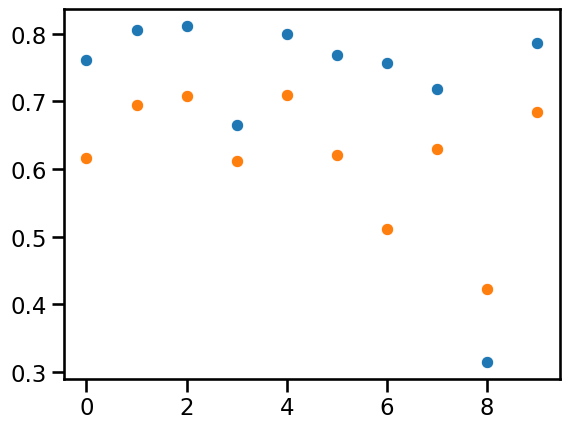

In [5]:
import seaborn as sns

_ = sns.scatterplot(data=cv_lr['test_score'])
_ = sns.scatterplot(data=cv_dtr['test_score'])

# Q2

In [21]:
from sklearn.model_selection import GridSearchCV
import numpy as np

max_depths = np.arange(1, 16, 1)
max_depths = {
    'max_depth': max_depths
}
gcv = GridSearchCV(
    DecisionTreeRegressor(),
    param_grid=max_depths,
    cv=10
)

In [22]:
cv_dtr_varied = cross_validate(
    gcv,
    data_numerical,
    target,
    cv=10,
    return_estimator=True
)

In [23]:
best_max_depths = []
for est in cv_dtr_varied['estimator']:
    best_max_depths.append(list(est.best_params_.values())[0])

In [24]:
np.mean(best_max_depths)

np.float64(7.0)

# Q3

In [46]:
gcv_tuned = gcv
gcv_tuned.estimator.set_params(random_state=None)

cv_dtr_tuned = cross_validate(
    gcv_tuned,
    data_numerical,
    target,
    cv=10,
    return_estimator=True
)

best_max_depths_tuned = []
for est in cv_dtr_tuned['estimator']:
    best_max_depths_tuned.append(list(est.best_params_.values())[0])
np.mean(best_max_depths_tuned)

np.float64(7.4)

<Axes: >

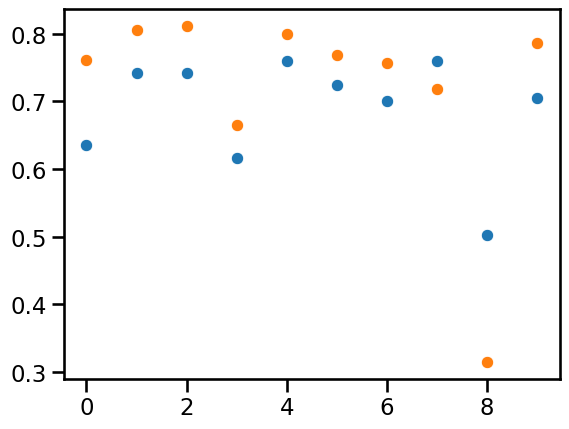

In [47]:
sns.scatterplot(data=cv_dtr_tuned['test_score'])
sns.scatterplot(data=cv_lr['test_score'])

# Q4

In [68]:
from sklearn.preprocessing import OrdinalEncoder
from sklearn.compose import make_column_selector, make_column_transformer
from sklearn.pipeline import make_pipeline

data_numerical = data_numerical
categorical_selector = make_column_selector(dtype_include=object)
categorical_features = categorical_selector(data)
data_categorical = data[categorical_features]

In [96]:
preprocessor = make_column_transformer(
    (OrdinalEncoder(handle_unknown="use_encoded_value", unknown_value=-1), categorical_features),
    ("passthrough", numerical_features)
)

pipeline = make_pipeline(
    preprocessor,
    DecisionTreeRegressor(max_depth=7, random_state=2)
)

In [97]:
cv_full_fixed = cross_validate(
    pipeline,
    data,
    target,
    cv=10
)

<Axes: >

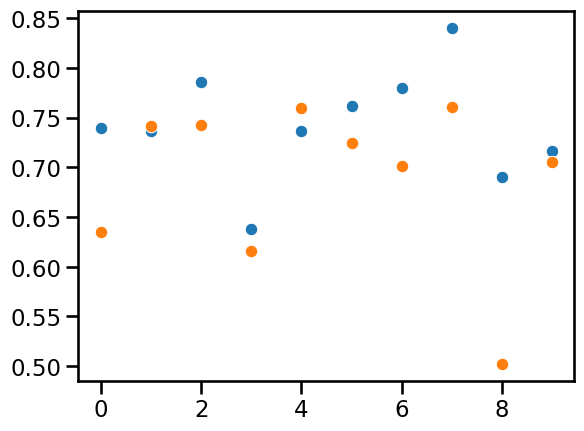

In [98]:
sns.scatterplot(data=cv_full_fixed['test_score'])
sns.scatterplot(data=cv_dtr_tuned['test_score'])

# Remarks - Use passthrough on data when no preprocessing is done